#### Loan Prediction Project
This project predicts whether a loan will be approved or not using Machine Learning.


### Problem Statement
The goal is to predict loan approval based on applicant details like income, education, employment, etc.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
dataset=pd.read_csv("loan_approval_dataset.csv")


In [3]:
df=dataset

In [4]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [5]:
df.isnull()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,False,False,False,False,False,False,False,False,False,False,False,False,False
4265,False,False,False,False,False,False,False,False,False,False,False,False,False
4266,False,False,False,False,False,False,False,False,False,False,False,False,False
4267,False,False,False,False,False,False,False,False,False,False,False,False,False


### Data Cleaning


In [6]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [7]:
df.columns = df.columns.str.strip()

In [8]:
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

## Encoding Categorical Variables

### Issue Faced:
Categorical columns like `education` and `self_employed` were in object format, which cannot be used directly in machine learning models.

### Solution:
- Used Label Encoding for `self_employed` (binary values)
- Used One-Hot Encoding for `education` to avoid ordinal bias

### Why different methods?
- `self_employed` has Yes/No → Label Encoding is sufficient  
- `education` has multiple categories → One-Hot Encoding is better

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Using LabelEncoder for binary categorical column
df['self_employed'] = le.fit_transform(df['self_employed'])
df['loan_status'] = le.fit_transform(df['loan_status'])

In [ ]:
# Removing spaces to avoid mismatch in categories
df['education'] = df['education'].astype(str).str.replace(' ', '')

# One-hot encoding for education
df = pd.get_dummies(df, columns=['education'])


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   loan_id                   4269 non-null   int64
 1   no_of_dependents          4269 non-null   int64
 2   self_employed             4269 non-null   int64
 3   income_annum              4269 non-null   int64
 4   loan_amount               4269 non-null   int64
 5   loan_term                 4269 non-null   int64
 6   cibil_score               4269 non-null   int64
 7   residential_assets_value  4269 non-null   int64
 8   commercial_assets_value   4269 non-null   int64
 9   luxury_assets_value       4269 non-null   int64
 10  bank_asset_value          4269 non-null   int64
 11  loan_status               4269 non-null   int64
 12  education_Graduate        4269 non-null   bool 
 13  education_NotGraduate     4269 non-null   bool 
dtypes: bool(2), int64(12)
memory usage: 408.

In [13]:
df.head()

,loan_id,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_Graduate,education_NotGraduate
0,1,2,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0,True,False
1,2,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1,False,True
2,3,3,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1,True,False
3,4,3,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1,True,False
4,5,5,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1,False,True


In [14]:
df.isnull().sum()

loan_id                     0
no_of_dependents            0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
education_Graduate          0
education_NotGraduate       0
dtype: int64

In [15]:
df.head()

,loan_id,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_Graduate,education_NotGraduate
0,1,2,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0,True,False
1,2,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1,False,True
2,3,3,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1,True,False
3,4,3,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1,True,False
4,5,5,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1,False,True


In [16]:
df.shape

(4269, 14)

### Exploratory Data Analysis (EDA)

- Visualized distribution of income
- Analyzed relationship between education and loan approval
- Checked correlation between features

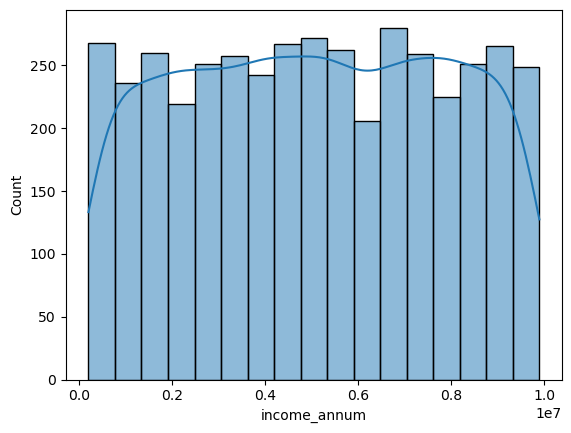

In [17]:
sns.histplot(df['income_annum'], kde=True)
plt.show()

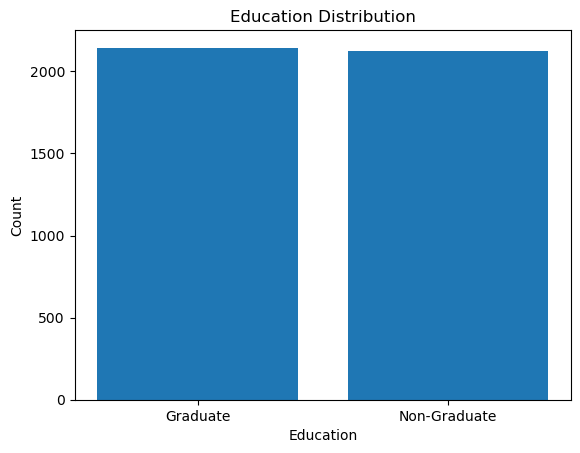

In [18]:
graduate_count = df['education_Graduate'].sum()
non_graduate_count = len(df) - graduate_count

labels = ['Graduate', 'Non-Graduate']
values = [graduate_count, non_graduate_count]

plt.bar(labels, values)
plt.title("Education Distribution")
plt.xlabel("Education")
plt.ylabel("Count")
plt.show()

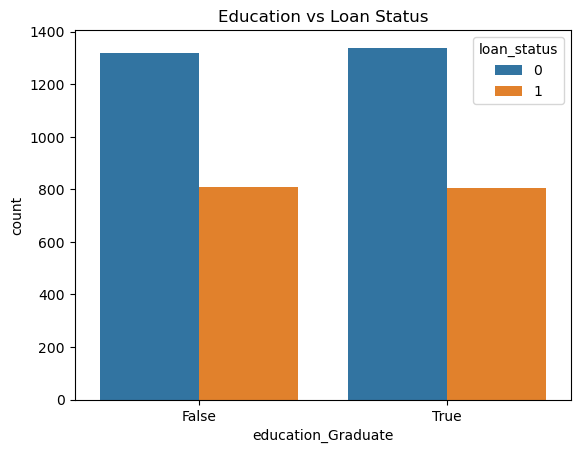

In [19]:

sns.countplot(x='education_Graduate', hue='loan_status', data=df)
plt.title("Education vs Loan Status")
plt.show()

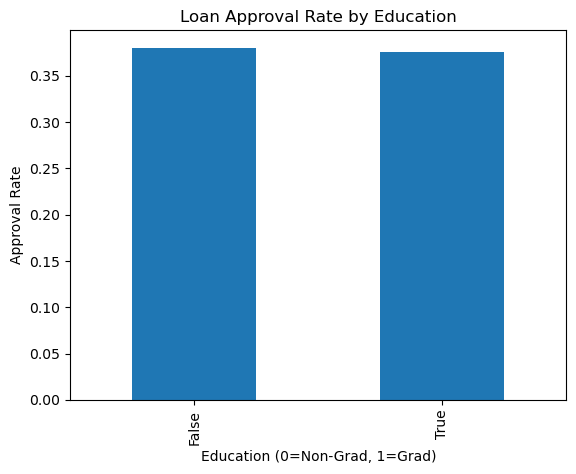

In [20]:
approval_rate = df.groupby('education_Graduate')['loan_status'].mean()

approval_rate.plot(kind='bar')
plt.title("Loan Approval Rate by Education")
plt.xlabel("Education (0=Non-Grad, 1=Grad)")
plt.ylabel("Approval Rate")
plt.show()

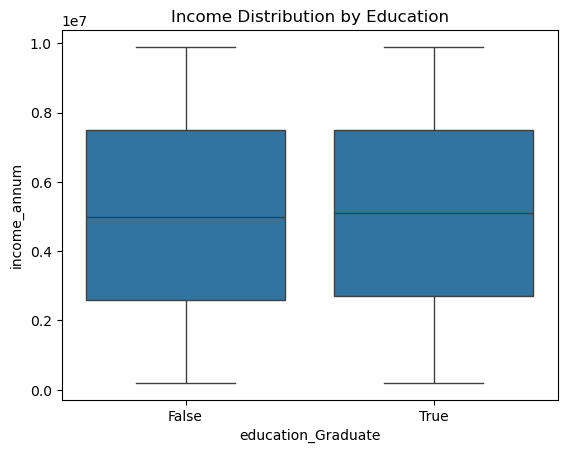

In [21]:
sns.boxplot(x='education_Graduate', y='income_annum', data=df)
plt.title("Income Distribution by Education")
plt.show()

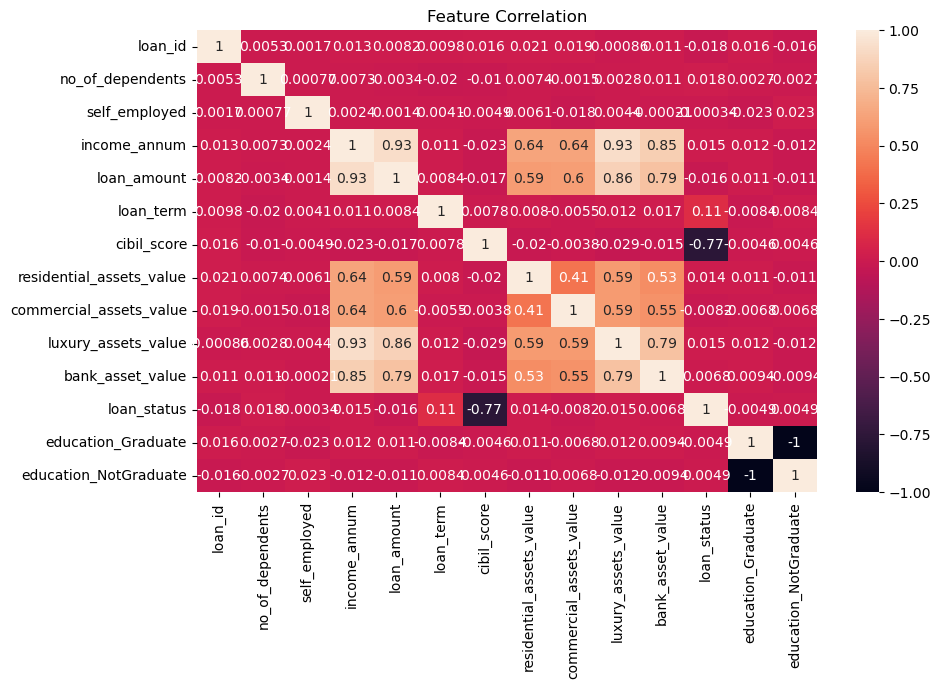

In [22]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

## Feature Engineering

### New Features Created:
- `total_assets`: Sum of all assets
- `loan_risk`: Ratio of loan amount to assets
- `dependents_income_pressure`: Financial burden indicator

### Why?
These features help the model better understand financial risk and applicant capacity.

### Columns Dropped:
- `loan_id`: Not useful for prediction
- `income_annum`: Removed to reduce redundancy or multicollinearity
- `education_Not Graduate`: Removed to reduce redundancy or multicollinearity

In [ ]:
df.drop('education_Not Graduate', axis=1, inplace=True)

In [24]:
df.drop('loan_id', axis=1, inplace=True)

In [25]:
df.drop('income_annum', axis=1, inplace=True)

In [26]:
df['total_assets'] = (
    df['residential_assets_value'] +
    df['commercial_assets_value'] +
    df['luxury_assets_value'] +
    df['bank_asset_value']
)

df.drop([
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'
], axis=1, inplace=True)

In [27]:
df.columns

Index(['no_of_dependents', 'self_employed', 'loan_amount', 'loan_term',
       'cibil_score', 'loan_status', 'education_Graduate',
       'education_NotGraduate', 'total_assets'],
      dtype='object')

<Axes: xlabel='loan_status', ylabel='count'>

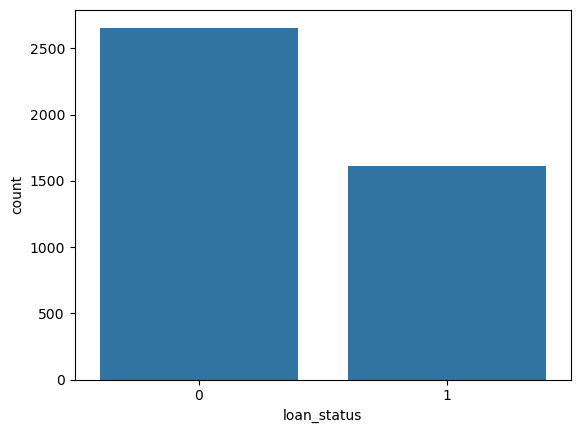

In [28]:
sns.countplot(x='loan_status', data=df)

<Axes: xlabel='loan_status', ylabel='cibil_score'>

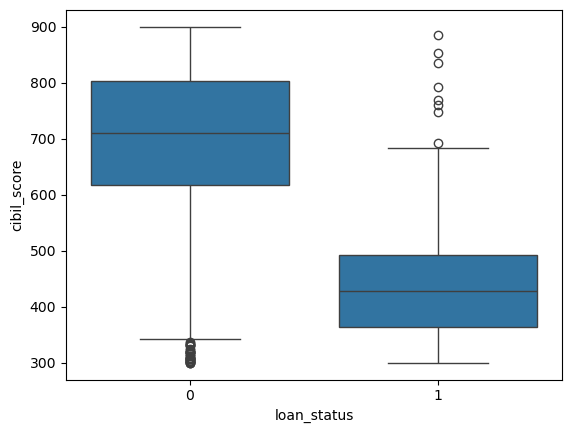

In [29]:
sns.boxplot(x='loan_status', y='cibil_score', data=df)

<Axes: xlabel='loan_status', ylabel='loan_amount'>

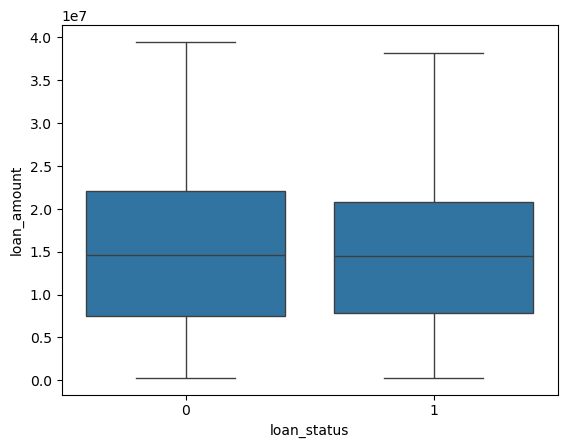

In [30]:
sns.boxplot(x='loan_status', y='loan_amount', data=df)

<Axes: xlabel='loan_status', ylabel='total_assets'>

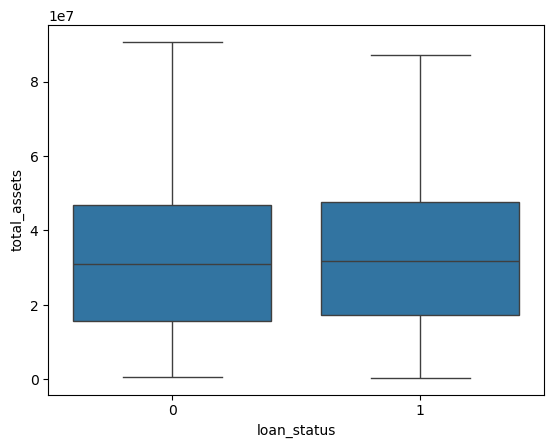

In [31]:
sns.boxplot(x='loan_status', y='total_assets', data=df)

<Axes: >

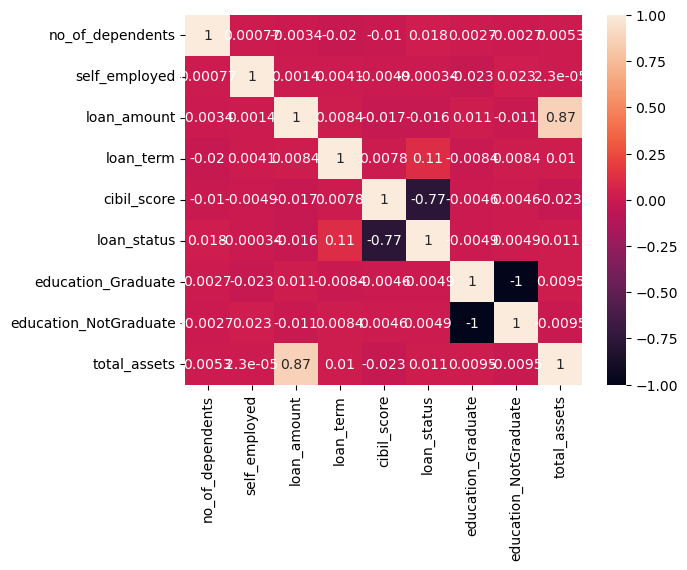

In [32]:
sns.heatmap(df.corr(), annot=True)

In [33]:
df['loan_risk'] = df['loan_amount'] / (df['total_assets'] + 1)

In [34]:
df['dependents_income_pressure'] = df['no_of_dependents'] * df['loan_amount']

## Model Training

### Issue:
The model was trained multiple times with different configurations.

### Reason:
- To experiment with different hyperparameters
- To improve model performance
- To test different solver settings

### Note:
Final model should be clearly defined to avoid confusion.

In [35]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initial model training
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [39]:
y_pred = model.predict(X_test)

## Issue Faced: Re-training Model

The dataset was split and model was trained multiple times unnecessarily.

### Why this is a problem?
- Can overwrite previous model
- Creates confusion in workflow
- Makes results inconsistent

### Fix:
Keep only one clean training pipeline.

In [40]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [41]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.5199063231850117


In [42]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[337 209]
 [201 107]]


In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.63      0.62      0.62       546
           1       0.34      0.35      0.34       308

    accuracy                           0.52       854
   macro avg       0.48      0.48      0.48       854
weighted avg       0.52      0.52      0.52       854



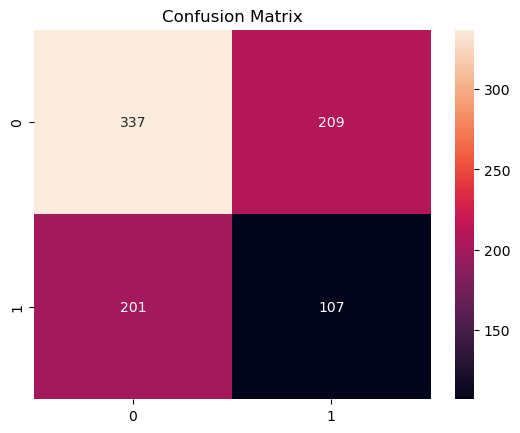

In [44]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [45]:
print(model.coef_)

[[ 2.80329099e-02 -3.81171560e-03 -6.95478670e-01  8.02459601e-01
  -4.04736615e+00 -2.81763768e-02  2.81763768e-02  6.08675589e-01
   1.00120258e-01 -2.95455801e-02]]


In [ ]:
# Trying different hyperparameters for better performance
model = LogisticRegression(C=0.1)


In [ ]:
# Changing solver for better convergence
model = LogisticRegression(solver='liblinear')

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Split
X = df.drop('loan_status', axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9156908665105387


In [49]:
new_data = [[
    2,        # no_of_dependents
    1,        # self_employed
    500000,   # loan_amount
    10,       # loan_term
    750,      # cibil_score
    1,        # education_Graduate
    2000000,  # total_assets
    0,        # loan_risk (we will calculate)
    0         # dependents_income_pressure (we will calculate)
]]

In [50]:
loan_amount = 500000
total_assets = 2000000
no_dep = 2

loan_risk = loan_amount / (total_assets + 1)
dependents_income_pressure = no_dep * loan_amount

In [51]:
new_data = [[
    2,
    1,
    500000,
    10,
    750,
    1,
    2000000,
    loan_risk,
    dependents_income_pressure
]]

In [52]:
new_data_scaled = scaler.transform(new_data)

prediction = model.predict(new_data_scaled)

print(prediction)

f:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


ValueError: X has 9 features, but StandardScaler is expecting 10 features as input.

In [ ]:
model.predict_proba(new_data_scaled)

NameError: name 'new_data_scaled' is not defined

In [ ]:
df.drop('dependents_income_pressure', axis=1, inplace=True)

## Prediction

- Created new input data manually
- Scaled input using trained scaler
- Predicted loan approval status

In [ ]:
def predict_loan(no_dep, self_emp, loan_amt, loan_term, cibil, edu_grad, assets):
    
    import pandas as pd
    
    new_data = pd.DataFrame([{
        'no_of_dependents': no_dep,
        'self_employed': self_emp,
        'loan_amount': loan_amt,
        'loan_term': loan_term,
        'cibil_score': cibil,
        'education_Graduate': edu_grad,
        'total_assets': assets
    }])
    
    # Feature engineering
    new_data['loan_risk'] = new_data['loan_amount'] / (new_data['total_assets'] + 1)
    
    # 🔥 IMPORTANT: match training columns
    new_data = new_data.reindex(columns=X.columns, fill_value=0)
    
    # Scale
    new_scaled = scaler.transform(new_data)
    
    # Predict
    pred = model.predict(new_scaled)[0]
    prob = model.predict_proba(new_scaled)[0]
    
    print("Prediction:", "Approved ✅" if pred == 1 else "Rejected ❌")
    print(f"Probabilities -> Reject: {prob[0]:.2f}, Approve: {prob[1]:.2f}")

In [ ]:
predict_loan(
    no_dep=2,
    self_emp=1,
    loan_amt=500000,
    loan_term=10,
    cibil=750,
    edu_grad=1,
    assets=2000000
)

Prediction: Approved ✅
Probabilities -> Reject: 0.00, Approve: 1.00


In [ ]:
no_dep = int(input("Dependents: "))
self_emp = int(input("Self employed (1/0): "))
loan_amt = float(input("Loan amount: "))
loan_term = int(input("Loan term: "))
cibil = int(input("CIBIL score: "))
edu = int(input("Graduate (1/0): "))
assets = float(input("Total assets: "))

predict_loan(no_dep, self_emp, loan_amt, loan_term, cibil, edu, assets)


Prediction: Approved ✅
Probabilities -> Reject: 0.00, Approve: 1.00


#### Again i train two time for checking accuracy

In [ ]:
# Step 1: Define new X (without that column)
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# Step 2: Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Step 3: Scale (NEW scaler)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 4: Train (NEW model)
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
no_dep = int(input("Dependents: "))
self_emp = int(input("Self employed (1/0): "))
loan_amt = float(input("Loan amount: "))
loan_term = int(input("Loan term: "))
cibil = int(input("CIBIL score: "))
edu = int(input("Graduate (1/0): "))
assets = float(input("Total assets: "))

predict_loan(no_dep, self_emp, loan_amt, loan_term, cibil, edu, assets)

Prediction: Rejected ❌
Probabilities -> Reject: 1.00, Approve: 0.00


## Model Interpretation (Feature Importance)

We extracted the coefficients from the Logistic Regression model to understand how each feature affects loan approval.

### Explanation:
- Each feature has a coefficient (weight)
- Positive coefficient → increases probability of loan approval
- Negative coefficient → decreases probability of loan approval
- Higher magnitude → stronger influence on prediction

This helps in understanding which factors are most important in decision-making.

In [ ]:
for col, coef in zip(X.columns, model.coef_[0]):
    print(col, coef)

no_of_dependents 0.038800748960229545
self_employed -0.07753608182154284
loan_amount -0.7348087584606736
loan_term 0.7791143328305952
cibil_score -4.007761294878546
education_Graduate -0.0143770764704093
education_NotGraduate 0.01437707647040969
total_assets 0.6790926306630932
loan_risk 0.15517554972447442


In [ ]:
df['loan_status'].value_counts()

loan_status
0    2656
1    1613
Name: count, dtype: int64

In [ ]:
df.groupby('loan_status')['cibil_score'].mean()

loan_status
0    703.461973
1    429.468072
Name: cibil_score, dtype: float64

In [ ]:
df['loan_status'] = 1 - df['loan_status']

### This one is final model training which predict right and give good accuracy

In [55]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)



LogisticRegression()

In [ ]:
no_dep = int(input("Dependents: "))
self_emp = int(input("Self employed (1/0): "))
loan_amt = float(input("Loan amount: "))
loan_term = int(input("Loan term: "))
cibil = int(input("CIBIL score: "))
edu = int(input("Graduate (1/0): "))
assets = float(input("Total assets: "))

predict_loan(no_dep, self_emp, loan_amt, loan_term, cibil, edu, assets)

Prediction: Approved ✅
Probabilities -> Reject: 0.00, Approve: 1.00


## Conclusion

- Logistic Regression was used for prediction
- Feature engineering improved model understanding
- Further improvements can be done using advanced models like Random Forest